# Regression & Classification 

# LAB 1: Regression 

โค้ดสำหรับโหลดข้อมูล ทำความสะอาดคอลัมน์ Height และ Weight ให้เป็นตัวเลข และจัดการกับค่า Missing Values

In [1]:
import pandas as pd
import numpy as np

# โหลด Dataset
df = pd.read_csv('Demon Slayer.csv')

# ทำความสะอาดข้อมูล Height (ลบคำว่า 'cm' ออกแล้วแปลงเป็น float)
df['Height_clean'] = (
    df['Height']
    .str.replace(' cm', '', regex=False)
    .str.replace('cm', '', regex=False)
    .astype(float)
)

# ทำความสะอาดข้อมูล Weight (ลบคำว่า 'kg' ออกแล้วแปลงเป็น float)
df['Weight_clean'] = (
    df['Weight']
    .str.replace(' kg', '', regex=False)
    .str.replace('kg', '', regex=False)
)
df['Weight_clean'] = pd.to_numeric(df['Weight_clean'], errors='coerce')

# เลือกเฉพาะคอลัมน์ที่จะใช้และตัดแถวที่มีค่าว่างออก
df_reg = df[['Age', 'Height_clean', 'Weight_clean']].dropna()

print(df_reg.head())

    Age  Height_clean  Weight_clean
0  16.0         165.0          61.0
1  14.0         153.0          45.0
2  16.0         164.0          53.0
3  15.0         165.0          55.0
4  16.0         158.0          45.0


ใช้ฟีเจอร์เดียวคือ Height_clean เพื่อทำนาย Age

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# กำหนด Features (X) และ Label (y)
X = df_reg[['Height_clean']]
y = df_reg['Age']

# แบ่งข้อมูลสำหรับ Train และ Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# สร้างและฝึกสอนโมเดล Simple Linear Regression
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

# ทำนายผล
y_pred_simple = simple_model.predict(X_test)

# แสดงผลลัพธ์
print('--- Simple Linear Regression ---')
print(f'Coefficients: {simple_model.coef_[0]:.4f}')
print(f'Intercept: {simple_model.intercept_:.4f}')
print(
    f'Mean Squared Error (MSE):'
    f' {mean_squared_error(y_test, y_pred_simple):.4f}'
)
print(f'R2 Score: {r2_score(y_test, y_pred_simple):.4f}')

--- Simple Linear Regression ---
Coefficients: 7.3591
Intercept: -1165.5988
Mean Squared Error (MSE): 15047.3299
R2 Score: -5.7602


ใช้หลายฟีเจอร์ (Height_clean และ Weight_clean) ร่วมกันเพื่อทำนาย Age

In [3]:
# กำหนด Features (X) ใช้ทั้งส่วนสูงและน้ำหนัก
X_multi = df_reg[['Height_clean', 'Weight_clean']]
y = df_reg['Age']

# แบ่งข้อมูล Train / Test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# สร้างและฝึกสอนโมเดล Multiple Linear Regression
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

# ทำนายผล
y_pred_multi = multi_model.predict(X_test_m)

# แสดงผลลัพธ์
print('--- Multiple Linear Regression ---')
print(f'Coefficients: {multi_model.coef_}')
print(f'Intercept: {multi_model.intercept_:.4f}')
print(
    f'Mean Squared Error (MSE):'
    f' {mean_squared_error(y_test_m, y_pred_multi):.4f}'
)
print(f'R2 Score: {r2_score(y_test_m, y_pred_multi):.4f}')

--- Multiple Linear Regression ---
Coefficients: [ 8.09733751 -0.77721985]
Intercept: -1242.9400
Mean Squared Error (MSE): 13080.3276
R2 Score: -4.8765


โค้ดสำหรับพล็อตกราฟเปรียบเทียบผลลัพธ์ของ Simple Linear Regression

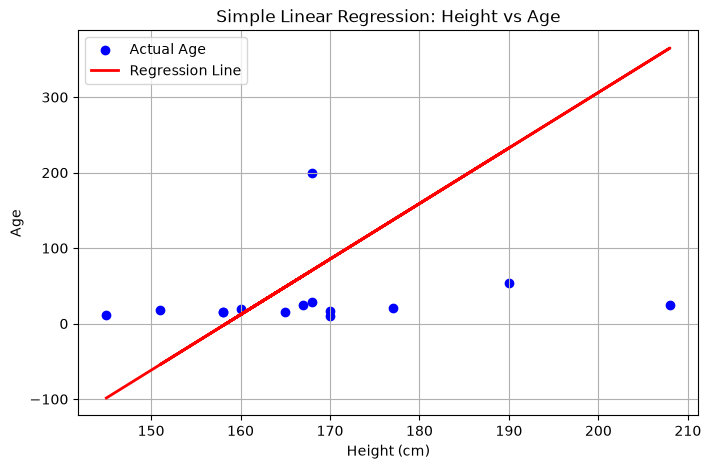

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Age')
plt.plot(
    X_test,
    y_pred_simple,
    color='red',
    linewidth=2,
    label='Regression Line',
)
plt.title('Simple Linear Regression: Height vs Age')
plt.xlabel('Height (cm)')
plt.ylabel('Age')
plt.legend()
plt.grid(True)
plt.show()

# LAB 2: Classification 

โค้ดสำหรับเตรียมข้อมูล จัดการค่า Missing Values และแปลงป้ายกำกับเพศ (Gender) ให้เป็นตัวเลข (Male = 1, Female = 0) เพื่อใช้ทำ Classification

In [7]:
import pandas as pd
import numpy as np

# โหลด Dataset
df = pd.read_csv('Demon Slayer.csv')

# ทำความสะอาดข้อมูลตัวเลข (Height, Weight, Age)
df['Height_clean'] = (
    df['Height']
    .str.replace(' cm', '', regex=False)
    .str.replace('cm', '', regex=False)
    .astype(float)
)
df['Weight_clean'] = pd.to_numeric(
    df['Weight']
    .str.replace(' kg', '', regex=False)
    .str.replace('kg', '', regex=False),
    errors='coerce',
)
df['Age_clean'] = df['Age'].fillna(df['Age'].median())
df['Weight_clean'] = df['Weight_clean'].fillna(df['Weight_clean'].median())

# แปลง Target (Gender) เป็นตัวเลข: Male = 1, Female = 0
df['Gender_target'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

# เลือก Features และ Target
X = df[['Height_clean', 'Weight_clean', 'Age_clean']]
y = df['Gender_target']

print(df[['Name', 'Gender', 'Gender_target', 'Height_clean']].head())

                Name  Gender  Gender_target  Height_clean
0     Tanjiro Kamado    Male              1         165.0
1      Nezuko Kamado  Female              0         153.0
2   Zenitsu Agatsuma    Male              1         164.0
3  Inosuke Hashibira    Male              1         165.0
4      Kanao Tsuyuri  Female              0         158.0


โค้ดสำหรับแบ่งข้อมูล Train/Test และสร้างโมเดล Logistic Regression เพื่อทำนายเพศตัวละคร

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# แบ่งข้อมูลสำหรับฝึกสอนและทดสอบ (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# สร้างและฝึกสอนโมเดล Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# ทำนายผลบนชุดทดสอบ
y_pred = model.predict(X_test)
print('Predicted:', y_pred)
print('Actual:   ', y_test.values)

Predicted: [1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1]
Actual:    [1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 0 0]


โค้ดสำหรับประเมินประสิทธิภาพโมเดลด้วย Confusion Matrix, Accuracy, Precision, Recall และ F1-score

In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# คำนวณตัวชี้วัดต่างๆ
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

print(f'Accuracy: {acc:.4f}\n')
print('Confusion Matrix:')
print(cm)
print('\nClassification Report:')
print(report)

Accuracy: 0.8235

Confusion Matrix:
[[5 3]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.75      1.00      0.86         9

    accuracy                           0.82        17
   macro avg       0.88      0.81      0.81        17
weighted avg       0.87      0.82      0.82        17



โค้ดสำหรับพล็อตกราฟแสดงขอบเขตการตัดสินใจ (Decision Boundary) โดยใช้ 2 ฟีเจอร์หลัก (Height และ Weight)

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


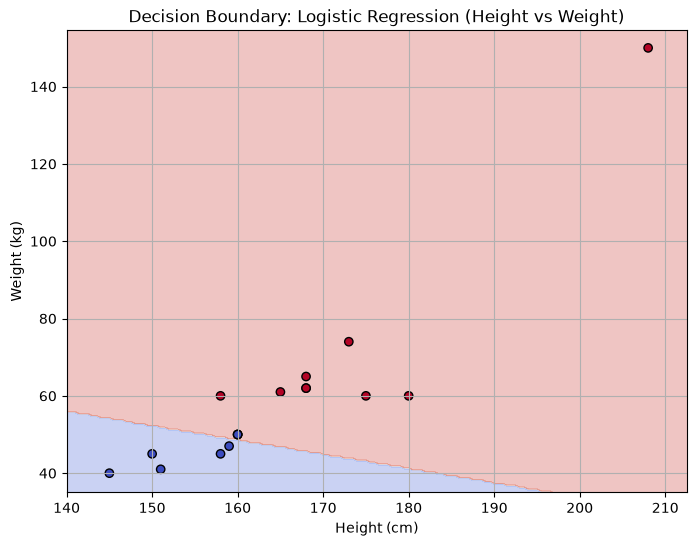

In [10]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ใช้ 2 ฟีเจอร์เพื่อให้พล็อตกราฟ 2 มิติได้ง่าย
X_2d = df[['Height_clean', 'Weight_clean']]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

# เทรนโมเดลด้วย 2 ฟีเจอร์
model_2d = LogisticRegression()
model_2d.fit(X_train_2d, y_train_2d)

# สร้าง Grid สำหรับพล็อตกราฟ Decision Boundary
x_min, x_max = X_2d['Height_clean'].min() - 5, X_2d['Height_clean'].max() + 5
y_min, y_max = X_2d['Weight_clean'].min() - 5, X_2d['Weight_clean'].max() + 5
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(
    X_test_2d['Height_clean'],
    X_test_2d['Weight_clean'],
    c=y_test_2d,
    edgecolors='k',
    cmap=plt.cm.coolwarm,
)
plt.title('Decision Boundary: Logistic Regression (Height vs Weight)')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.grid(True)
plt.show()

# LAB 3: Model Comparison 

Simple vs Multiple Linear Regression
โค้ดสำหรับเปรียบเทียบประสิทธิภาพระหว่าง Simple Linear Regression (ใช้ส่วนสูงอย่างเดียวทำนายอายุ) กับ Multiple Linear Regression (ใช้ทั้งส่วนสูงและน้ำหนัก)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. เตรียมข้อมูล
X_simple = df_reg[['Height_clean']]
X_multi = df_reg[['Height_clean', 'Weight_clean']]
y_reg = df_reg['Age']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_simple, y_reg, test_size=0.2, random_state=42
)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_reg, test_size=0.2, random_state=42
)

# 2. เทรนโมเดลและทำนายผล
reg_s = LinearRegression().fit(Xs_train, ys_train)
reg_m = LinearRegression().fit(Xm_train, ym_train)

pred_s = reg_s.predict(Xs_test)
pred_m = reg_m.predict(Xm_test)

# 3. แสดงผลเปรียบเทียบค่า R2 และ MSE
print('--- Simple Linear Regression Performance ---')
print(f'R2 Score: {r2_score(ys_test, pred_s):.4f}')
print(f'MSE: {mean_squared_error(ys_test, pred_s):.4f}')

print('\n--- Multiple Linear Regression Performance ---')
print(f'R2 Score: {r2_score(ym_test, pred_m):.4f}')
print(f'MSE: {mean_squared_error(ym_test, pred_m):.4f}')

--- Simple Linear Regression Performance ---
R2 Score: -5.7602
MSE: 15047.3299

--- Multiple Linear Regression Performance ---
R2 Score: -4.8765
MSE: 13080.3276


โค้ดสำหรับตรวจสอบประสิทธิภาพระหว่างชุดข้อมูลฝึกสอน (Training Set) และชุดข้อมูลทดสอบ (Testing Set) เพื่อเช็คการเกิด Overfitting

In [13]:
# ทำนายผลบนชุด Train และ Test ของ Multiple Linear Regression
train_pred = reg_m.predict(Xm_train)
test_pred = reg_m.predict(Xm_test)

train_r2 = r2_score(ym_train, train_pred)
test_r2 = r2_score(ym_test, test_pred)

print(f'Training R2 Score: {train_r2:.4f}')
print(f'Testing R2 Score:  {test_r2:.4f}')

Training R2 Score: 0.1018
Testing R2 Score:  -4.8765


โค้ดรวมสรุปตัวชี้วัดประสิทธิภาพของโมเดลทั้งฝั่ง Regression และ Classification เพื่อนำไปใส่ตารางรายงาน LAB 3

In [14]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# สรุปผล Metrics ฝั่ง Regression
print('=== Regression Metrics ===')
print(f'MAE: {mean_absolute_error(ym_test, test_pred):.4f}')
print(f'MSE: {mean_squared_error(ym_test, test_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(ym_test, test_pred)):.4f}')
print(f'R2: {r2_score(ym_test, test_pred):.4f}')

# สรุปผล Metrics ฝั่ง Classification (จาก LAB 2)
# สมมติว่ามี y_test และ y_pred จาก Logistic Regression แล้ว
# print("=== Classification Metrics ===")
# print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
# print(classification_report(y_test, y_pred))

=== Regression Metrics ===
MAE: 84.8481
MSE: 13080.3276
RMSE: 114.3693
R2: -4.8765
